In [1]:
from pydub import AudioSegment
from pydub.playback import play
import numpy as np


In [2]:
audio = AudioSegment.from_mp3("speech_sample.mp3")

In [3]:
rate = audio.frame_rate
print(f"rate: {rate}")
channels = audio.channels
print(f"channels: {channels}")      # 1 = mono, 2 = stereo
sample_width = audio.sample_width
print(f"sample width: {sample_width}")  # bytes per sample (e.g. 2 for int16)
duration = len(audio) / 1000.0  # duration in seconds
minute = int(duration // 60)
second = int(duration % 60)
print(f"duration: {minute} min {second} sec")

rate: 44100
channels: 2
sample width: 2
duration: 41 min 6 sec


In [4]:
samples = np.array(audio.get_array_of_samples()).astype(np.float32)
samples /= np.max(np.abs(samples))
# handle stereo
if channels == 2:
    samples = samples.reshape((-1, 2))


In [5]:
def border_samples(rate, start=None, end=None):
    start_sample = int(rate * start) if start is not None else 0
    end_sample = int(rate * end) if end is not None else len(samples)
    return start_sample, end_sample

def play_np(samples, rate, start=None, end=None, sample_width=2):
    samples = samples / np.max(np.abs(samples))
    samples_int16 = (samples * 32767).astype(np.int16)
    start_sample, end_sample = border_samples(rate, start, end)
    samples_int16 = samples_int16[start_sample:end_sample]
    audio = AudioSegment(
        samples_int16.tobytes(),
        frame_rate=rate,
        sample_width=sample_width,
        channels=1 if samples.ndim == 1 else samples.shape[1]
    )

    play(audio)
    return start_sample, end_sample


In [6]:
#play_np(samples, rate, start=10, end=13, sample_width=sample_width)

In [7]:
#audio.export("speech_sample.wav", format="wav")

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from stft import *

In [9]:
argument = stft_argument()
stft = STFT(argument)
sound = SoundData(sample_rate=rate)

In [10]:
start, end = border_samples(rate, start=10, end=13)

In [11]:
sound.set(samples[start:end])

(<Figure size 640x480 with 1 Axes>, <Axes: >)

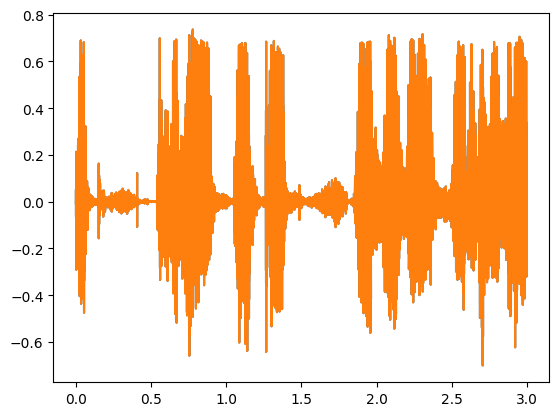

In [12]:
sound.plot()

In [13]:
stft(samples[start:end,0])

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='time (s)', ylabel='frequency (Hz)'>,
 <matplotlib.collections.QuadMesh at 0x7397e854d130>)

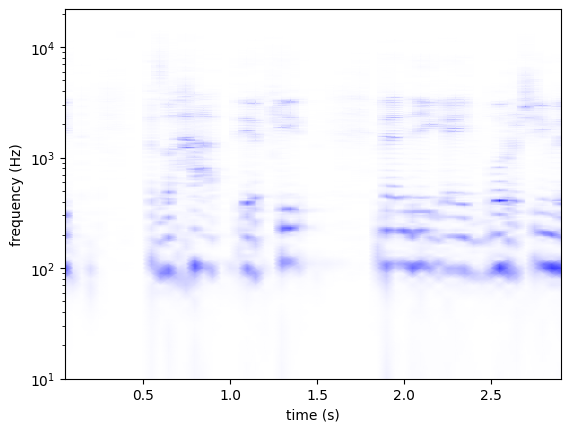

In [14]:
stft.plot()

(<Figure size 640x480 with 1 Axes>, <Axes: >)

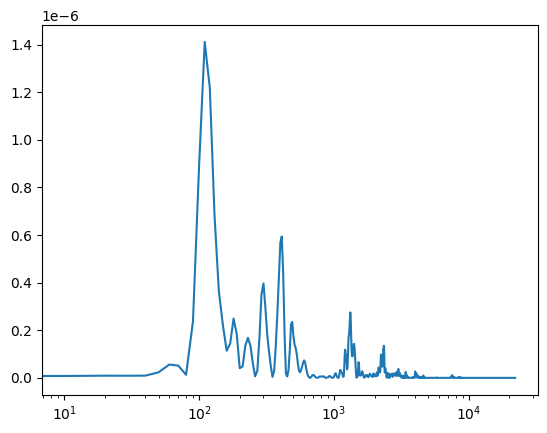

In [16]:
stft.plot_spectrum(0.6)